In [1]:
import numpy as np
from scipy.integrate import odeint
from scipy.stats import kendalltau
from scipy.stats import entropy
from matplotlib import pyplot as plt
import sdeint
import math

# m goes from 0.25 to 0.352.


# Define simulation functions
def run_WC_model(tmax,tstep,m,init,n):
    t = np.arange(0, tmax, tstep)
    lent=len(t) 
    
    L=2000
    a=0.25
    s=0.75
    w=27000
    
    def f(HF, t):
        H=HF[0]
        F=HF[1]
        dH = L*((H+F)/(w+H+F))-H*(a-s*F/(H+F))
        dF = H*(a-s*F/(H+F))-m*F
        return np.array([dH, dF])
    
    def g(x, t):
        dg = np.diag([n, n])
        return dg   
    
    result=sdeint.itoint(f, g, init, t)
    return result

### Estimate changes in eigenvalues

In [3]:
init2=np.array([5697.22436226, 1724.98073959])
init3=np.array([208.81061253,  55.36934326])

L=2000
a=0.25
s=0.75
w=27000
m=0.25
H,F=init2

Ja = L*w/((w+H+F)**2)-a-(s*F**2)/((H+F)**2)
Jb = L*w/((w+H+F)**2) + (s*H**2)/((H+F)**2)
Jc = a - s*F**2/((H+F)**2)
Jd= - s*H**2/((H+F)**2) - m

J25=np.array([[Ja,Jb],[Jc,Jd]])

m=0.35
H,F=init3

Ja = L*w/((w+H+F)**2)-a-(s*F**2)/((H+F)**2)
Jb = L*w/((w+H+F)**2) + (s*H**2)/((H+F)**2)
Jc = a - s*F**2/((H+F)**2)
Jd= - s*H**2/((H+F)**2) - m

J35=np.array([[Ja,Jb],[Jc,Jd]])

In [5]:
np.linalg.eig(J25)

EigResult(eigenvalues=array([-0.07846311, -0.85837109]), eigenvectors=array([[ 0.9463384 , -0.62214231],
       [ 0.32317741,  0.78290418]]))

In [7]:
np.linalg.eig(J35)

EigResult(eigenvalues=array([-0.05620968, -0.97265218]), eigenvectors=array([[ 0.96177702, -0.5788773 ],
       [ 0.27383381,  0.81541466]]))

## Simulate synthetic data
And save them in a .npy database

In [ ]:
# This is the part that generates the time series. It takes quite a long time to run, but once the file is created it does not need to be ran again.
tmax=10000
tstep=0.01
t = np.arange(0, tmax, tstep)

TS=np.zeros((len(t),11))
ms=np.arange(0.25,0.36,0.01)

for i in range(11):
    print(i)
    m=ms[i]
    if i==0:
        init = init2
    else: # Take out p% and stabilize for tm steps (depending on m) without noise
        p=round(0.1+0.28*(10*(m-0.25))) #p is 10% for m=0.25 and 38% for m=0.35 and increases linearly 
        init = result[-1,:] - p*result[-1,:]
        tm=round(300+4700*(10*(m-0.25))) # tm is 300 for m=0.25 and 5000 for m=0.35 and increases linearly
        if i>8:
            tm += 10000 # system becomes very slow for values of m close to 0.35
        result=run_WC_model(tm,tstep,m,init,0)
        init = result[-1,:]
        
    result=run_WC_model(tmax,tstep,m,init,0.01)
    while math.isnan(result[-1,0]):
        print('a')
        result=run_WC_model(tmax,tstep,m,init,0.01)
    TS[:,i]=result[:,0]+result[:,1] #save total colony size

TS2=np.reshape(np.transpose(TS),(TS.shape[0]*TS.shape[1]))
plt.figure(figsize=(15,5))
plt.plot(TS2)

#np.save('timeseries_WC_m025.npy',TS) # commented out so it is not accidentally overwritten 

## Load .npy database and perform analysis
And create figures for the paper

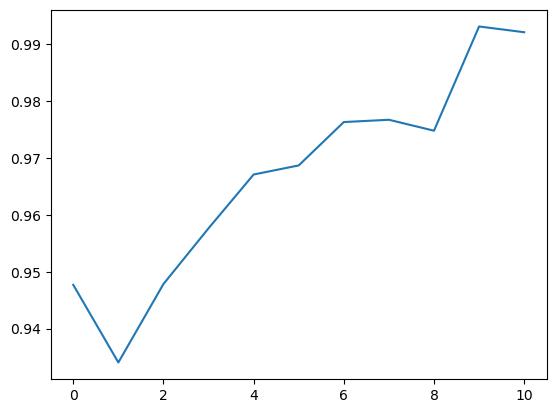

In [10]:
TS=np.load('timeseries_WC_m025.npy')


# Look at one sample of AC(1)
ACs=np.zeros(11)
for i in range(11):
    data=TS[0::400,i]
    ACs[i]=np.corrcoef(data[1:],data[0:-1])[0,1]

plt.plot(ACs)
    

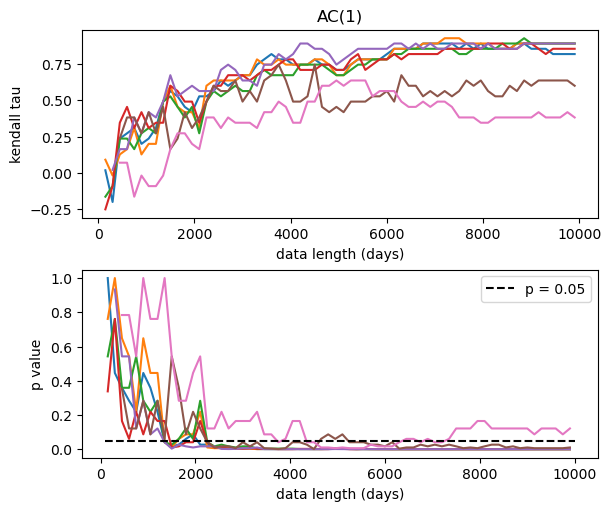

In [109]:
# Using all datapoints, test the effect of having lower and lower resolutions (i.e., how many datapoints I sample - the bigger \rho, the lower the sampling frequency)

TS=np.load('timeseries_WC_m025.npy') #load time series

data_L=np.arange(15000,1000001,15000) # Even when refining the step further, the first instance when p-value < 0.05 is about at 1500 days, so I keep a sufficiently high step to allow visualization withoiut impeding the detection after 4+ years
data_res=[1, 700, 3000, 5000,10000,15000,20000] #(days/dt = days*100)

ll = len(data_L)

fig, axs = plt.subplots(2, 1, figsize=(6, 5), layout='compressed')

for j in range(len(data_res)):
    kendalltaus=np.zeros(ll)
    pvalues=np.zeros(ll)
    for k in range(ll):
        data=TS[0:data_L[k]:data_res[j],:]
        
        ACs=np.zeros(11)
        for i in range(11):
            data2=data[:,i]
            ACs[i]=np.corrcoef(data2[1:],data2[0:-1])[0,1]
    
        kendalltaus[k]=kendalltau(ACs,np.arange(11))[0]
        pvalues[k]=kendalltau(ACs,np.arange(11))[1]
    plt.subplot(2,1,1)
    plt.plot(data_L/100,kendalltaus,label= r'$\rho$ = '+str(data_res[j]/100)) # Resolution (every how many points I sample)
    plt.xlabel('data length (days)')
    plt.ylabel('kendall tau')
    plt.title('AC(1)')
    
    plt.subplot(2,1,2)
    plt.plot(data_L/100,pvalues)
    plt.xlabel('data length (days)')
    plt.ylabel('p value')

plt.plot([100,10000],[0.05,0.05],'--k',label='p = 0.05')
plt.legend()
#plt.subplot(2,1,1)
#plt.legend()

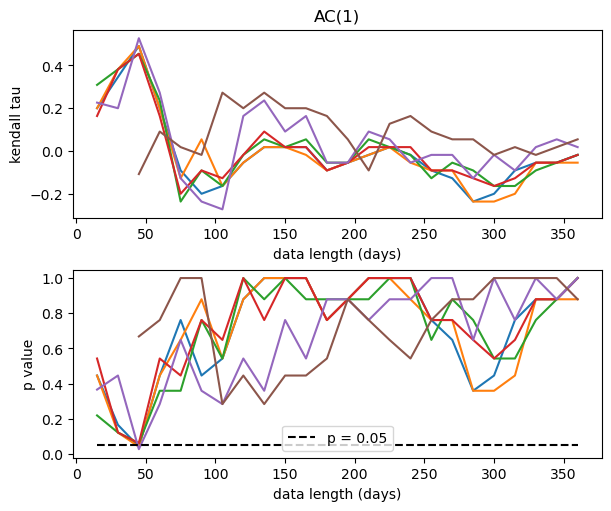

In [95]:
# Using all datapoints, test the effect of having lower and lower resolutions (i.e., how many datapoints I sample - the bigger \rho, the lower the sampling frequency)

TS=np.load('timeseries_WC_m025.npy') #load time series

data_L=np.arange(1500,36500,1500) # Even when refining the step further, the first instance when p-value < 0.05 is about at 1500 days, so I keep a sufficiently high step to allow visualization withoiut impeding the detection after 4+ years
data_res=[1, 10, 50, 100, 700, 1500] #(days/dt = days*100)

lll = len(data_L)

fig, axs = plt.subplots(2, 1, figsize=(6, 5), layout='compressed')

for j in range(len(data_res)):
    kendalltaus=np.zeros(lll)
    pvalues=np.zeros(lll)
    for k in range(lll):
        data=TS[0:data_L[k]:data_res[j],:]
        
        ACs=np.zeros(11)
        for i in range(11):
            data2=data[:,i]
            ACs[i]=np.corrcoef(data2[1:],data2[0:-1])[0,1]
    
        kendalltaus[k]=kendalltau(ACs,np.arange(11))[0]
        pvalues[k]=kendalltau(ACs,np.arange(11))[1]
    plt.subplot(2,1,1)
    plt.plot(data_L/100,kendalltaus,label= r'$\rho$ = '+str(data_res[j]/100)) # Resolution (every how many points I sample)
    plt.xlabel('data length (days)')
    plt.ylabel('kendall tau')
    plt.title('AC(1)')
    
    plt.subplot(2,1,2)
    plt.plot(data_L/100,pvalues)
    plt.xlabel('data length (days)')
    plt.ylabel('p value')

plt.plot([min(data_L)/100,max(data_L)/100],[0.05,0.05],'--k',label='p = 0.05')
plt.legend()
#plt.subplot(2,1,1)
#plt.legend()

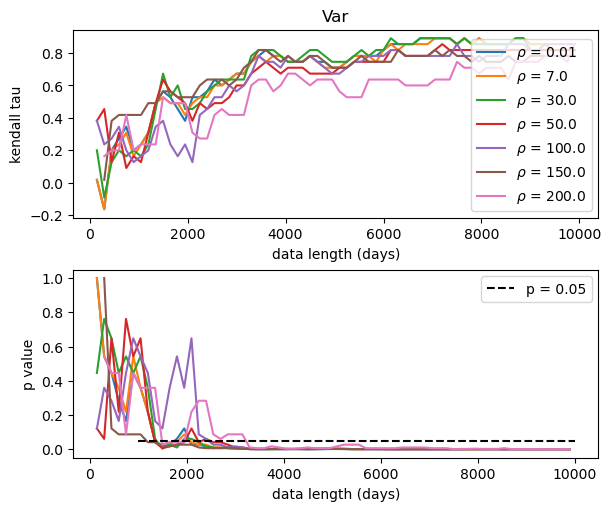

In [71]:
# Variance, for the full time series

data_L=np.arange(15000,1000001,15000) # Even when refining the step further, the first instance when p-value < 0.05 is about at 1500 days, so I keep a sufficiently high step to allow visualization withoiut impeding the detection after 4+ years
data_res=[1, 700, 3000, 5000,10000,15000,20000] #(days/dt = days*100)

fig, axs = plt.subplots(2, 1, figsize=(6, 5), layout='compressed')

#plt.figure()
for j in range(len(data_res)):
    kendalltaus=np.zeros(ll)
    pvalues=np.zeros(ll)
    for k in range(ll):
        data=TS[0:data_L[k]:data_res[j],:]
        
        Vars=np.zeros(11)
        for i in range(11):
            data2=data[:,i]
            Vars[i]=np.var(data2)
    
        kendalltaus[k]=kendalltau(Vars,np.arange(11))[0]
        pvalues[k]=kendalltau(Vars,np.arange(11))[1]
    plt.subplot(2,1,1)
    plt.plot(data_L/100,kendalltaus,label=r'$\rho$ = '+str(data_res[j]/100))
    plt.xlabel('data length (days)')
    plt.ylabel('kendall tau')
    plt.title('Var')
    
    plt.subplot(2,1,2)
    plt.plot(data_L/100,pvalues)
    plt.xlabel('data length (days)')
    plt.ylabel('p value')

plt.plot([100,10000],[0.05,0.05],'--k',label='p = 0.05')
plt.legend()
plt.subplot(2,1,1)
plt.legend()

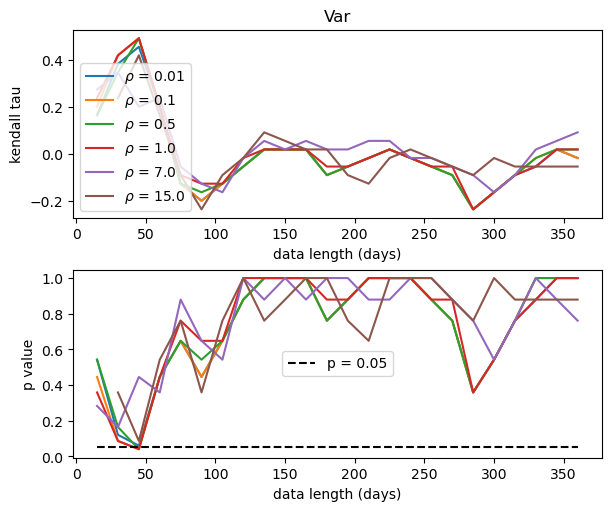

In [99]:
# Variance, for the full time series

data_L=np.arange(1500,36500,1500) # Even when refining the step further, the first instance when p-value < 0.05 is about at 1500 days, so I keep a sufficiently high step to allow visualization withoiut impeding the detection after 4+ years
data_res=[1, 10, 50, 100, 700, 1500] #(days/dt = days*100)

fig, axs = plt.subplots(2, 1, figsize=(6, 5), layout='compressed')

#plt.figure()
for j in range(len(data_res)):
    kendalltaus=np.zeros(lll)
    pvalues=np.zeros(lll)
    for k in range(lll):
        data=TS[0:data_L[k]:data_res[j],:]
        
        Vars=np.zeros(11)
        for i in range(11):
            data2=data[:,i]
            Vars[i]=np.var(data2)
    
        kendalltaus[k]=kendalltau(Vars,np.arange(11))[0]
        pvalues[k]=kendalltau(Vars,np.arange(11))[1]
    plt.subplot(2,1,1)
    plt.plot(data_L/100,kendalltaus,label=r'$\rho$ = '+str(data_res[j]/100))
    plt.xlabel('data length (days)')
    plt.ylabel('kendall tau')
    plt.title('Var')
    
    plt.subplot(2,1,2)
    plt.plot(data_L/100,pvalues)
    plt.xlabel('data length (days)')
    plt.ylabel('p value')

plt.plot([min(data_L)/100,max(data_L)/100],[0.05,0.05],'--k',label='p = 0.05')
plt.legend()
plt.subplot(2,1,1)
plt.legend()

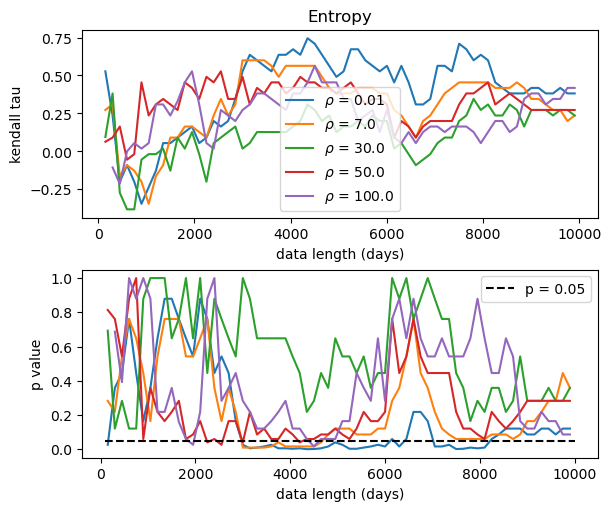

In [113]:
# Entropy

data_L=np.arange(15000,1000001,15000) # Even when refining the step further, the first instance when p-value < 0.05 is about at 1500 days, so I keep a sufficiently high step to allow visualization withoiut impeding the detection after 4+ years
data_res=[1, 700, 3000, 5000,10000,15000,20000] #(days/dt = days*100)

fig, axs = plt.subplots(2, 1, figsize=(6, 5), layout='compressed')

#plt.figure()
for j in range(5):
    kendalltaus=np.zeros(ll)
    pvalues=np.zeros(ll)
    for k in range(ll):
        data=TS[0:data_L[k]:data_res[j],:]
        
        Ents=np.zeros(11)
        for i in range(11):
            data2=data[:,i]
            pk=np.histogram(data2,density=True)[0]
            Ents[i]=entropy(pk)
    
        kendalltaus[k]=kendalltau(Ents,np.arange(11))[0]
        pvalues[k]=kendalltau(Ents,np.arange(11))[1]
    plt.subplot(2,1,1)
    plt.plot(data_L/100,kendalltaus,label=r'$\rho$ = '+str(data_res[j]/100))
    plt.xlabel('data length (days)')
    plt.ylabel('kendall tau')
    plt.title('Entropy')
    
    plt.subplot(2,1,2)
    plt.plot(data_L/100,pvalues)
    plt.xlabel('data length (days)')
    plt.ylabel('p value')

plt.plot([100,10000],[0.05,0.05],'--k',label='p = 0.05')
plt.legend()
plt.subplot(2,1,1)
plt.legend()

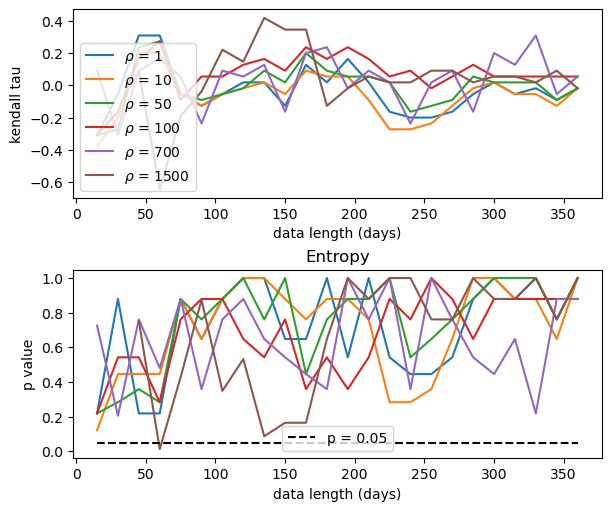

In [117]:
data_L=np.arange(1500,36500,1500) # Even when refining the step further, the first instance when p-value < 0.05 is about at 1500 days, so I keep a sufficiently high step to allow visualization withoiut impeding the detection after 4+ years
data_res=[1, 10, 50, 100, 700, 1500] #(days/dt = days*100)

fig, axs = plt.subplots(2, 1, figsize=(6, 5), layout='compressed')

plt.title('Entropy')
#plt.figure()
for j in range(len(data_res)):
    kendalltaus=np.zeros(len(data_L))
    pvalues=np.zeros(len(data_L))
    for k in range(len(data_L)):
        data=TS[-(data_L[k])::data_res[j],:]
        
        Ents=np.zeros(11)
        for i in range(11):
            data2=data[:,i]
            pk=np.histogram(data2,density=True)[0]
            Ents[i]=entropy(pk)
    
        kendalltaus[k]=kendalltau(Ents,np.arange(11))[0]
        pvalues[k]=kendalltau(Ents,np.arange(11))[1]
    plt.subplot(2,1,1)
    plt.plot(data_L/100,kendalltaus,label=r'$\rho$ = '+str(data_res[j]))
    plt.xlabel('data length (days)')
    plt.ylabel('kendall tau')
    
    plt.subplot(2,1,2)
    plt.plot(data_L/100,pvalues)
    plt.xlabel('data length (days)')
    plt.ylabel('p value')

plt.plot([min(data_L)/100,max(data_L)/100],[0.05,0.05],'--k',label='p = 0.05')
plt.legend()

plt.subplot(2,1,1)
plt.legend()